In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  

from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from dataclasses import dataclass
from sklearn.model_selection import KFold
from imblearn.pipeline import pipeline
import scipy
from imblearn.over_sampling import SMOTE

import sys
sys.path.append(r"/run/media/drdrakken/Elements/Sonstiges/Programmieren/Machine Learning")

from MLUtilitys import PlotManager, ParamGrid, MLCodeGenerator

In [2]:
import os
print(os.getcwd())   

/run/media/drdrakken/Elements/Sonstiges/Programmieren/Machine Learning/Part 8 - Deep Learning/Section 39 - Artificial Neural Networks (ANN)/Part 11 - Ml Portfolio


In [3]:
linux_path = r"/run/media/drdrakken/Elements/Sonstiges/Programmieren/Machine Learning/csvs/titanic.csv"
windows_path = r"I:\Sonstiges\Programmieren\Machine Learning/csvs/titanic.csv"
df = pd.read_csv(linux_path)
df.drop(["Name" , "PassengerId"], axis = 1)

,Survived,Pclass,Lname,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,Braund,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,Cumings,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,Heikkinen,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,Futrelle,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,Allen,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
151,1,1,Pears,female,22.0,1,0,113776,66.6000,C2,S
152,0,3,Meo,male,55.5,0,0,A.5. 11206,8.0500,NaN,S
153,0,3,van Billiard,male,40.5,0,2,A/5. 851,14.5000,NaN,S
154,0,3,Olsen,male,NaN,0,0,Fa 265302,7.3125,NaN,S


In [4]:
@dataclass
class Config():
    target:str = "Survived"
    seed : int = 1234
    test_size:int = 0.2
    hyperparameter_test_amount:int = 5
    cross_validation_amount:int = 5 
    verbose:int = 0
    
config = Config()

In [5]:
class DataClass():
    def __init__(self , DataFrame):
        self.data = DataFrame.copy()
        self.numerical_data = self.data.select_dtypes(include = np.number).columns
        self.categorical_data = self.data.select_dtypes(exclude = np.number).columns

        self.x = self.data.drop([config.target] , axis = 1)
        self.y = self.data[config.target]

data = DataClass(DataFrame = df)

In [6]:
class DataTransform():

    def fit(self , X , y = None):
        return self
    
    def transform(self, X , y = None):
        x = X.copy()
        x = self.new_features(x)
        return x
    
    def new_features(self , X , y = None):
        x = X.copy()
        x["family_size"] = x["SibSp"] + x["Parch"]
        x["age_group"] = pd.cut(
            df["Age"],
            bins = [
                0,
                15,
                30,
                45,
                np.inf,
            ],
            labels = [

                "Child",
                "Teenager",
                "YoungAdult",
                "Adult",
                

            ],

        )

        return x

In [7]:
class Preprocessor():

    def fit(self, X , y = None):
        numerical_data = X.select_dtypes(include = np.number).columns
        categorical_data = X.select_dtypes(exclude = np.number).columns

        self.preprocessor = ColumnTransformer([
            ("numerical_handler" , Pipeline([
                ("numerical_imputer" , SimpleImputer(strategy = "mean")),
                ("scaler" , MinMaxScaler()),
            ]),numerical_data),

            ("categorical_handler" , Pipeline([
                ("categorical_imputer" , SimpleImputer(strategy = "most_frequent")),
                ("categorical_encoder" , OneHotEncoder(handle_unknown="ignore" , sparse_output=False)),
            ]),categorical_data)
        ])
        self.preprocessor.fit(X)
        return self
    
    def transform(self , X , y = None):
        return self.preprocessor.transform(X)

In [8]:
def model_varianz():

    return {

        "LogisticRegression":LogisticRegression(random_state = config.seed),
        "DecisionTreeClassifier":DecisionTreeClassifier(random_state = config.seed),
        "RandomForestClassifier":RandomForestClassifier(random_state = config.seed),
        "LinearSVC":LinearSVC(random_state = config.seed),
        "XGBClassifier":XGBClassifier(random_state = config.seed),
        
    }

In [9]:
def custom_model_parameters():
    return {

        "LogisticRegression": {
            "estimator__C": scipy.stats.loguniform(1e-4, 1e2),
            "estimator__penalty": ["l2"],
            "estimator__solver": ["lbfgs"],
        },

        "DecisionTreeClassifier": {
            "estimator__criterion": ["gini", "entropy"],
            "estimator__max_depth": [None, 5, 10, 20],
            "estimator__min_samples_split": scipy.stats.randint(2, 20),
            "estimator__min_samples_leaf": scipy.stats.randint(1, 10),
        },

        "RandomForestClassifier": {
            "estimator__n_estimators": scipy.stats.randint(100, 500),
            "estimator__max_depth": scipy.stats.randint(5, 40),
            "estimator__min_samples_split": scipy.stats.randint(2, 20),
            "estimator__min_samples_leaf": scipy.stats.randint(1, 10),
            "estimator__max_features": ["sqrt", "log2"],
            "estimator__bootstrap": [True, False],
        },

        "LinearSVC": {
            "estimator__C": scipy.stats.loguniform(1e-4, 1e2),
            "estimator__loss": ["hinge", "squared_hinge"],
            "estimator__dual": [True],
            "estimator__max_iter": [5000, 10000],
        },

        "XGBClassifier": {
            "estimator__n_estimators": scipy.stats.randint(100, 500),
            "estimator__learning_rate": scipy.stats.loguniform(1e-3, 0.3),
            "estimator__max_depth": scipy.stats.randint(3, 10),
            "estimator__subsample": scipy.stats.uniform(0.6, 0.4),
            "estimator__colsample_bytree": scipy.stats.uniform(0.6, 0.4),
            "estimator__gamma": scipy.stats.uniform(0, 5),
            "estimator__min_child_weight": scipy.stats.randint(1, 10),
        },

    }


In [10]:
def custom_pipeline(estimator , transform = False, use_smote = False):

    steps = []
    if transform:
        steps.append(("Transformed Performance" , DataTransform()))

    steps.append(("Base_Transformation_Score" , Preprocessor()))
    
    if use_smote:
        steps.append(("use_smote" , SMOTE()))

    steps.append(("estimator" , estimator))
    return Pipeline(steps)

In [11]:
def custom_scoring_dict():

        return {

            "f1":"f1",
            "accuracy":"accuracy",
            "precision":"precision",

        }

In [12]:
def custom_data_validation(estimator , X_train , y_train ):
    
    k_fold = KFold(n_splits=5 , shuffle=True,random_state=config.seed)
    return cross_validate(estimator= estimator,
                          X=X_train,
                          y=y_train,
                          cv=k_fold,
                          n_jobs=config.hyperparameter_test_amount,
                          return_train_score=True,
                          scoring="accuracy",
                          verbose=config.verbose,
                          )


In [13]:
def custom_grid_search(estimator , X_train , y_train , scoring_dict , param_dist):
    grid =  RandomizedSearchCV(estimator= estimator,
                            cv=config.cross_validation_amount,
                            n_iter=config.hyperparameter_test_amount,
                            n_jobs=-1,
                            param_distributions=param_dist,
                            scoring=scoring_dict,
                            refit="accuracy",
                            return_train_score=True,
                    
                            )
    grid.fit(X_train , y_train )
    return grid

In [14]:
def data_split():
    X_train , X_test , y_train , y_test = train_test_split(data.x,
                                                           data.y,
                                                           test_size=config.test_size,
                                                           shuffle=True,
                                                           stratify=data.y)
    print(f"X_train_shape:{X_train.shape}")
    print(f"X_test_shape:{X_test.shape}")
    print(f"y_train_shape:{y_train.shape}")
    print(f"y_test_shape:{y_test.shape}")

    return X_train , X_test , y_train , y_test

In [15]:
def plot_scores(
        self,
        data,
        x_column,
        score_columns,
        title="Model Comparison",
        ylabel="Score"
    ):
        # Falls eine Liste von Dictionaries übergeben wird
        if isinstance(data, list):
            data = pd.DataFrame(data)

        x = range(len(data))

        plt.figure(figsize=(12, 6))

        for column in score_columns:
            if column in data.columns:
                plt.plot(
                    x,
                    data[column],
                    marker="o",
                    linewidth=2,
                    label=column
                )

        plt.xticks(x, data[x_column], rotation=45)
        plt.xlabel(x_column)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [16]:
class Benchmark():

    def __init__(self , UseCV = False , UseGrid= False):
        self.X_train , self.X_test , self.y_train , self.y_test = data_split()
        self.results = []

        self.use_cv = UseCV
        self.use_grid_search = UseGrid
        self.fit()

    def fit(self):

        for estimator_name , estimators in model_varianz().items():

            base_pipe = custom_pipeline(estimator=estimators , 
                                        transform=False , 
                                        use_smote= False)
            
            transformer_pipe = custom_pipeline(estimator=estimators , 
                                               transform=True , 
                                               use_smote = True)

            if self.use_cv:
                base_cv = custom_data_validation(estimator=base_pipe , 
                                                 X_train=self.X_train,
                                                 y_train=self.y_train,
                                                )
                
                transformed_cv = custom_data_validation(estimator=transformer_pipe,
                                                        X_train=self.X_train,
                                                        y_train=self.y_train,
                                                        )

                self.results.append({

                    "Estimator" : estimators,

                    "Base_cv_train_score":base_cv["train_score"].mean(),
                    "Base_cv_test_score":base_cv["test_score"].mean(),
                    "Base_cv_std_score":base_cv["test_score"].std(),

                    "Transformed_cv_train_score":transformed_cv["train_score"].mean(),
                    "Transformed_cv_test_score":transformed_cv["test_score"].mean(),
                    "Transformed_cv_std_score":transformed_cv["test_score"].std(),
                    
                })

            if self.use_grid_search:
                base_grid = custom_grid_search(estimator=base_pipe,
                                                      X_train=self.X_train,
                                                      y_train=self.y_train,
                                                    scoring_dict=custom_scoring_dict(),
                                                    param_dist=custom_model_parameters()[estimator_name])
                
                transformed_grid = custom_grid_search(estimator=base_pipe,
                                                      X_train=self.X_train,
                                                      y_train=self.y_train,
                                                    scoring_dict=custom_scoring_dict(),
                                                    param_dist=custom_model_parameters()[estimator_name])
                self.results.append({

                    "base_best_estimator":base_grid.best_estimator_,
                    "transformed_best_estimator":transformed_grid.best_estimator_,
                    
                })

        plot_scores(
            self,
            data=self.results,
            x_column="Estimator",
            score_columns=[
                "Base_cv_train_score",
                "Base_cv_test_score",
                "Base_cv_std_score",
                "Transformed_cv_train_score",
                "Transformed_cv_test_score",
                "Transformed_cv_std_score",
            ],
            title="Cross Validation Results",
            ylabel="Score"
        )

                
 

X_train_shape:(124, 12)
X_test_shape:(32, 12)
y_train_shape:(124,)
y_test_shape:(32,)


/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/drdrakken/.clean_venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/drdrakken/.clean_venv/

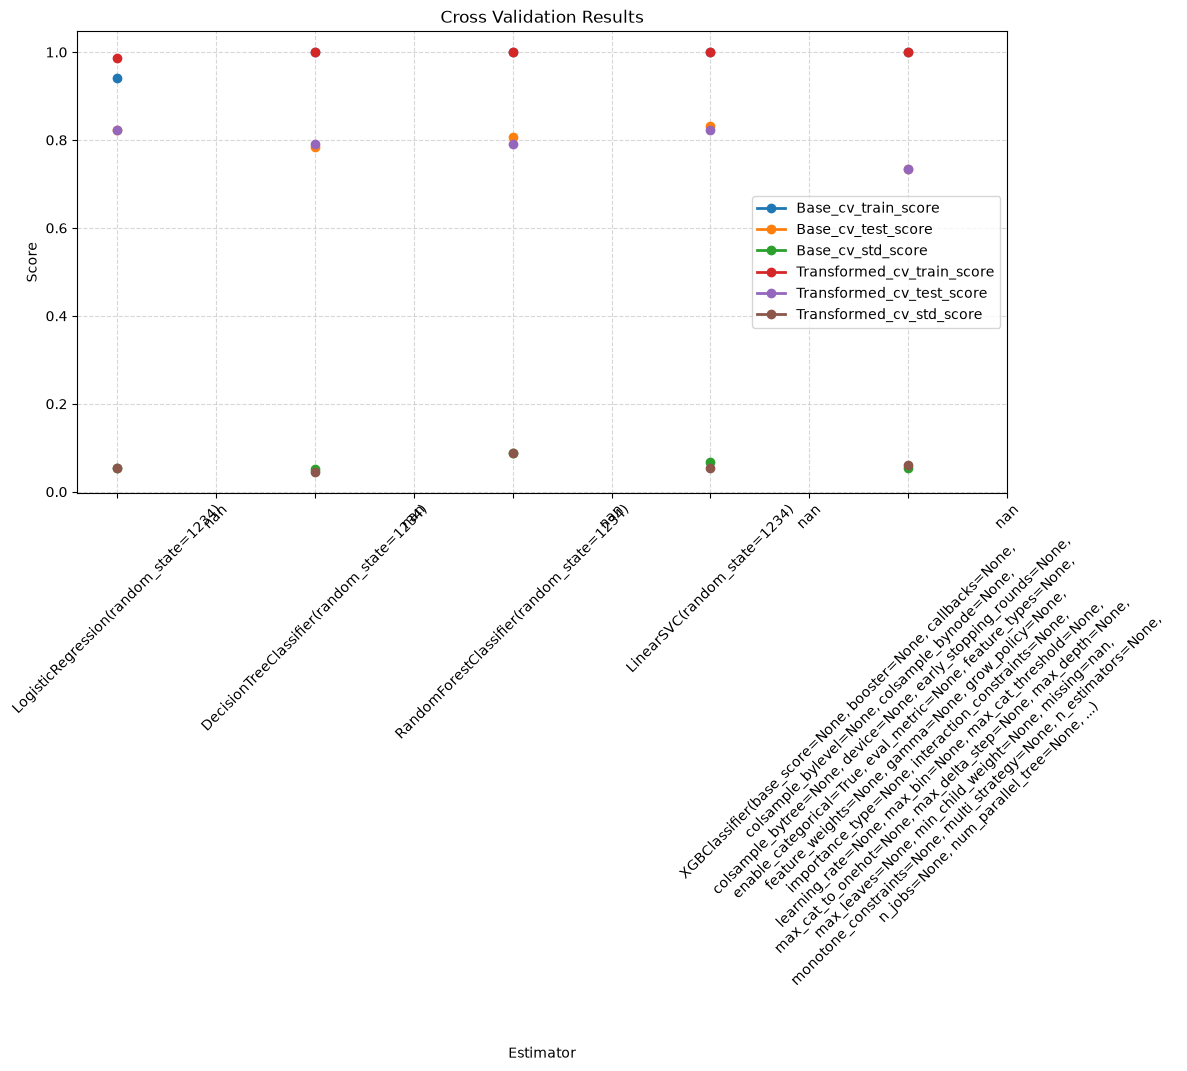

In [17]:
Benchmark(UseCV= True , UseGrid=True)